Ce notebook se divise en trois parties :

L'intuition analytique : Conjugaison (rapide).

La mécanique numérique : Implémentation d'un Metropolis-Hastings from scratch.

Le défi : Inférence sur un point de rupture (Change-point detection).

### Partie 0 : 
Le Cadre ThéoriqueRappel de la base. Nous cherchons la distribution a posteriori de paramètres $\theta$ sachant les données $D$ :$$P(\theta | D) = \frac{P(D | \theta) P(\theta)}{P(D)}$$Comme $P(D)$ est une constante de normalisation souvent intraitable (intégrale sur tout l'espace des paramètres), nous travaillons à une constante près :

$$P(\theta | D) \propto P(D | \theta) P(\theta)$$ $$\text{Posterior} \propto \text{Vraisemblance} \times \text{Prior}$$

# Partie 1 : 
L'intuition visuelle (Priors Conjugués)Pour commencer, observons comment la vraisemblance "tire" le prior vers les données. Nous utilisons le cas Beta-Binomial car la solution est analytique.
Modèle :
- Données : $k$ succès sur $n$ essais (Bernoulli).
- Paramètre : $\theta \in [0, 1]$ (probabilité de succès).
- Vraisemblance : Binomiale.
- Prior : $\theta \sim \text{Beta}(\alpha, \beta)$.

Exercice visuel :Exécute ce code. Modifie les hyperparamètres alpha_prior et beta_prior pour observer la "résistance" du prior face aux données.

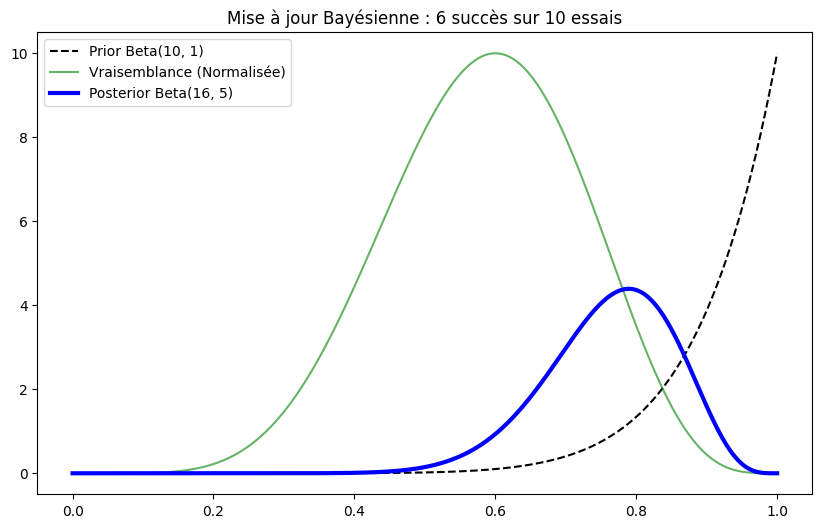

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def plot_beta_binomial(alpha_prior, beta_prior, successes, trials):
    theta = np.linspace(0, 1, 1000)
    
    # 1. Prior
    pdf_prior = beta.pdf(theta, alpha_prior, beta_prior)
    
    # 2. Likelihood (normalisée pour l'affichage uniquement)
    # L(theta) = theta^k * (1-theta)^(n-k)
    likelihood = theta**successes * (1-theta)**(trials - successes)
    likelihood = likelihood / np.max(likelihood) * np.max(pdf_prior) 
    
    # 3. Posterior (Analytique : propriété de conjugaison)
    # Le nouveau alpha est alpha + k, le nouveau beta est beta + n - k
    alpha_post = alpha_prior + successes
    beta_post = beta_prior + trials - successes
    pdf_post = beta.pdf(theta, alpha_post, beta_post)
    
    plt.figure(figsize=(10, 6))
    plt.plot(theta, pdf_prior, 'k--', label=f'Prior Beta({alpha_prior}, {beta_prior})')
    plt.plot(theta, likelihood, 'g-', alpha=0.6, label='Vraisemblance (Normalisée)')
    plt.plot(theta, pdf_post, 'b-', lw=3, label=f'Posterior Beta({alpha_post}, {beta_post})')
    plt.legend()
    plt.title(f"Mise à jour Bayésienne : {successes} succès sur {trials} essais")
    plt.show()

# À FAIRE : Simule un prior "têtu" (fortes valeurs d'alpha/beta) vs données contradictoires
plot_beta_binomial(alpha_prior=10, beta_prior=1, successes=6, trials=10)



### Partie 2 : 
Le Moteur (Metropolis-Hastings)Dans la réalité, les priors conjugués sont rares. Nous devons échantillonner $P(\theta | D)$ sans pouvoir calculer l'intégrale de normalisation $P(D)$.L'algorithme de Metropolis-Hastings génère une chaîne de Markov dont la distribution stationnaire est la distribution cible $P(\theta | D)$.

L'algorithme :

- Partir d'un paramètre courant $\theta_t$.
- Proposer un nouveau paramètre $\theta^*$ via une distribution de proposition symétrique $Q(\theta^* | \theta_t)$ (souvent $\mathcal{N}(\theta_t, \sigma)$).
- Calculer le ratio d'acceptation $\alpha$ :$$\alpha = \frac{P(D|\theta^*)P(\theta^*)}{P(D|\theta_t)P(\theta_t)}$$
- Accepter $\theta^*$ avec probabilité $\min(1, \alpha)$.

Travail à faire :Implémente la logique d'acceptation dans la fonction ci-dessous.Note : Pour la stabilité numérique, travaille toujours avec les logarithmes des probabilités (log_prob).$$\log(\alpha) = \log(P(D|\theta^*)P(\theta^*)) - \log(P(D|\theta_t)P(\theta_t))$$

Taux d'acceptation : 0.76


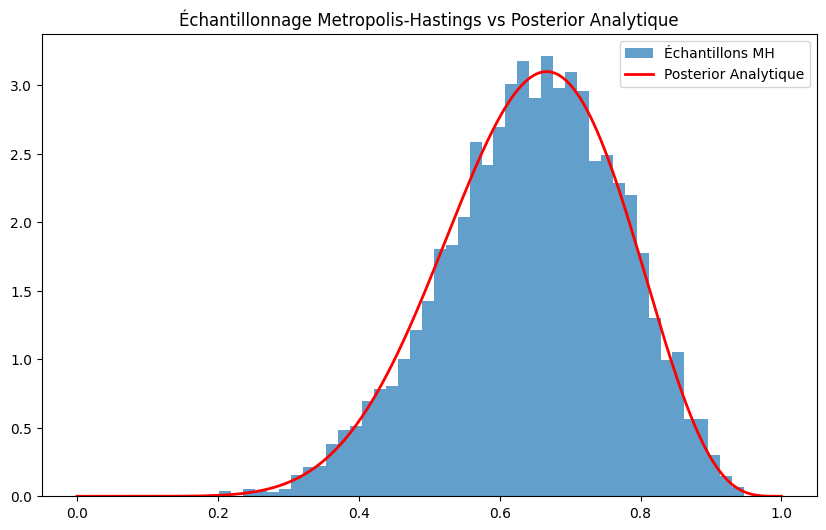

In [5]:
def log_posterior_func(theta):
    if theta < 0 or theta > 1:
        return -np.inf  # Log(0) pour des valeurs hors de [0,1]
    
    # Prior Beta(2,2)
    log_prior = (2 - 1) * np.log(theta) + (2 - 1) * np.log(1 - theta)
    
    # Likelihood Binomial(10, theta) avec 7 succès
    k = 7
    n = 10
    log_likelihood = k * np.log(theta) + (n - k) * np.log(1 - theta)
    
    return log_prior + log_likelihood


def metropolis_hastings(log_posterior_func, initial_theta, n_samples=5000, step_size=0.5):
    samples = [initial_theta]
    current_theta = initial_theta
    current_log_prob = log_posterior_func(current_theta)
    
    accepted_count = 0
    
    for _ in range(n_samples):
        # 1. Proposal (Random Walk)
        proposal = current_theta + np.random.normal(0, step_size)
        proposal_log_prob = log_posterior_func(proposal)
        
        # 2. Calcul du ratio d'acceptation (en log)
        # TODO: Écris la formule du log_acceptance_ratio
        log_alpha = proposal_log_prob - current_log_prob 

        # 3. Accept / Reject
        # On accepte si log(u) < log_alpha, où u ~ Uniform(0,1)
        if np.log(np.random.rand()) < log_alpha:
            current_theta = proposal
            current_log_prob = proposal_log_prob
            accepted_count += 1
            
        samples.append(current_theta)
        
    print(f"Taux d'acceptation : {accepted_count / n_samples:.2f}")
    return np.array(samples)

# Exécute l'algorithme Metropolis-Hastings
mh_samples = metropolis_hastings(log_posterior_func, initial_theta=0.1, n_samples=10000, step_size=0.1)
# Trace les résultats
plt.figure(figsize=(10, 6))
plt.hist(mh_samples, bins=50, density=True, alpha=0.7, label='Échantillons MH')
theta = np.linspace(0, 1, 1000)
pdf_post = beta.pdf(theta, 2 + 7, 2 + 10 - 7)  # Posterior analytique
plt.plot(theta, pdf_post, 'r-', lw=2, label='Posterior Analytique')
plt.title("Échantillonnage Metropolis-Hastings vs Posterior Analytique")
plt.legend()
plt.show()




### Partie 3 : 
Application (Détection de point de rupture)
Nous allons modéliser une série temporelle (exemple : nombre d'accidents par an) qui subit un changement soudain d'intensité.

Les Données (Génération) :

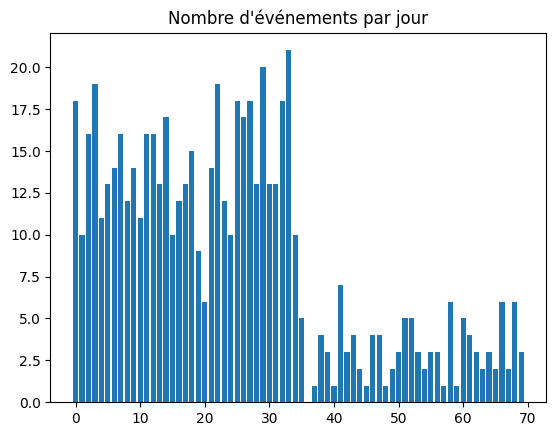

In [7]:
# Génération de données synthétiques
np.random.seed(42)
count_data = np.concatenate([
    np.random.poisson(15, 35),  # λ1 = 15 
    np.random.poisson(3, 35)    # λ2 = 8 
])
days = np.arange(len(count_data))

plt.bar(days, count_data)
plt.title("Nombre d'événements par jour")
plt.show()

### Le Modèle :
Nous avons trois inconnues : $\lambda_1$ (avant le changement), $\lambda_2$ (après), et $\tau$ (le jour du changement).
- Vraisemblance : $$y_t \sim \text{Poisson}(\lambda_1) \quad \text{si } t < \tau$$ 
$$y_t \sim \text{Poisson}(\lambda_2) \quad \text{si } t \ge \tau$$
- Priors :$$\lambda_1, \lambda_2 \sim \text{Exponential}(\alpha) \quad (\text{disons } \alpha = 1/\bar{y})$$
$$\tau \sim \text{Uniform}(0, N)$$

Travail à faire :Définis la fonction log_posterior_unnormalized qui prend en entrée le vecteur de paramètres theta $= [\lambda_1, \lambda_2, \tau]$ et renvoie une valeur proportionnelle à la log-probabilité a posteriori.

Rappel mathématique :La log-vraisemblance d'une loi de Poisson de paramètre $\lambda$ pour une observation $k$ est $k \ln(\lambda) - \lambda - \ln(k!)$. (Le terme $\ln(k!)$ est constant par rapport aux paramètres, tu peux l'ignorer).

In [8]:
def log_posterior_challenge(theta, data):
    lambda1, lambda2, tau = theta
    
    # Contraintes de domaine (Priors implicites : probabilité 0 si hors domaine)
    if lambda1 < 0 or lambda2 < 0 or tau < 0 or tau > len(data):
        return -np.inf
    
    tau = int(tau) # Tau est discret
    
    # 1. Log-Prior
    # Supposons des priors exponentiels simples  lpoures lambdas : P(λ) ~ exp(-λ) -> log ~ -λ
    # Prior uniforme pour tau -> log constant (on peut ignorer ou mettre 0)
    log_prior = -lambda1 - lambda2
    
    # 2. Log-Likelihood
    # TODO: Sépare les données en deux groupes selon tau
    # Calcule la log-vraisemblance de Poisson sur chaque segment
    
    # --- DÉBUT ZONE ÉTUDIANT ---
    
    data_before = data[:tau] 
    data_after = data[tau:]
    log_lik = np.sum(data_before * np.log(lambda1) - lambda1) + np.sum(data_after * np.log(lambda2) - lambda2)# (somme des log-probabilités de Poisson)
    
    # Indice : scipy.stats.poisson.logpmf est utile, ou coder manuellement :
    # sum(k * ln(lambda) - lambda)
    
    # --- FIN ZONE ÉTUDIANT ---
    
    return log_prior + log_lik

Taux d'acceptation : 0.10


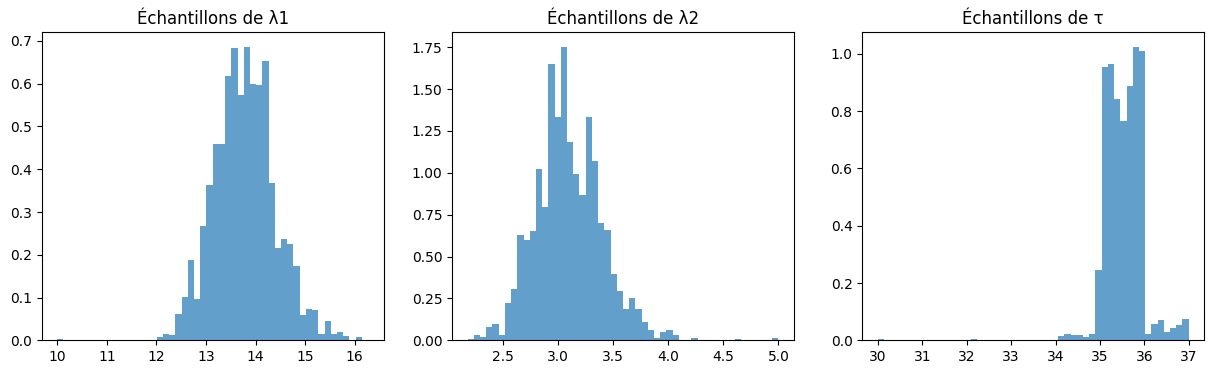

In [ ]:
# metropolis hastings vectoriel
def metropolis_hastings_vectoriel(log_posterior_func, initial_theta, n_samples=5000, step_size=0.5):
    samples = [initial_theta]
    current_theta = np.array(initial_theta)
    current_log_prob = log_posterior_func(current_theta)
    
    accepted_count = 0
    
    for _ in range(n_samples):
        # 1. Proposal (Random Walk Multivarié)
        proposal = current_theta + np.random.normal(0, step_size, size=current_theta.shape)
        proposal_log_prob = log_posterior_func(proposal)   
        # 2. Calcul du ratio d'acceptation (en log)
        log_alpha = proposal_log_prob - current_log_prob
        # 3. Accept / Reject
        if np.log(np.random.rand()) < log_alpha: # on accepte si oui
            current_theta = proposal
            current_log_prob = proposal_log_prob
            accepted_count += 1
        samples.append(current_theta)
    print(f"Taux d'acceptation : {accepted_count / n_samples:.2f}")
    return np.array(samples)

# Exécute l'algorithme Metropolis-Hastings pour le challenge
initial_theta = [10.0, 5.0, 30.0]
mh_samples_challenge = metropolis_hastings_vectoriel(
    lambda theta: log_posterior_challenge(theta, count_data),
    initial_theta=initial_theta,
    n_samples=10000,
    step_size=1.0
)
# Trace les résultats pour les paramètres
lambda1_samples = mh_samples_challenge[:, 0]
lambda2_samples = mh_samples_challenge[:, 1]
tau_samples = mh_samples_challenge[:, 2]
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(lambda1_samples, bins=50, density=True, alpha=0.7)
plt.title("Échantillons de λ1")
plt.subplot(1, 3, 2)
plt.hist(lambda2_samples, bins=50, density=True, alpha=0.7)
plt.title("Échantillons de λ2")
plt.subplot(1, 3, 3)
plt.hist(tau_samples, bins=50, density=True, alpha=0.7)
plt.title("Échantillons de τ")
plt.show()

In [ ]:
import numpy as np
from scipy.stats import poisson, expon

def log_posterior_change_point(theta, data):
    # theta = [lambda1, lambda2, tau]
    l1, l2, tau = theta
    n = len(data)
    
    # 1. Contraintes strictes (Support du Prior)
    if l1 < 0 or l2 < 0 or tau < 0 or tau >= n:
        return -np.inf
    
    # 2. Priors (Log-densités)
    # λ ~ Exp(alpha) => log P(λ) = log(alpha) - alpha*λ
    # On simplifie avec alpha=1 pour l'exercice
    log_prior = -l1 - l2  
    # Tau uniforme => log(1/n), constant, on l'ignore car proportionnel
    
    # 3. Vraisemblance (Vectorisée)
    idx = int(tau)
    # Données avant et après le point de rupture
    # Astuce : On calcule la log-vraisemblance de TOUT le vecteur pour l1 et l2
    # puis on masque. C'est souvent plus rapide en NumPy que le slicing répété.
    
    log_pmf_l1 = poisson.logpmf(data, l1) # Vecteur de taille n
    log_pmf_l2 = poisson.logpmf(data, l2) # Vecteur de taille n
    
    # Masque : 1 si t < tau, 0 sinon
    mask = np.arange(n) < idx
    
    log_likelihood = np.sum(log_pmf_l1[mask]) + np.sum(log_pmf_l2[~mask])
    
    return log_prior + log_likelihood

## Partie 2 : Théorie Avancée - L'échec de la marche aléatoire

Pourquoi ne pas utiliser Metropolis-Hastings (MH) tout le temps ?

Le problème de la concentration de la mesure :En haute dimension $D$, la masse de probabilité d'une distribution n'est pas au mode (où la densité est maximale), mais dans une coquille appelée l'Ensemble Typique.
- Le volume croit comme $r^D$.
- La densité décroit quand on s'éloigne du mode.
- L'intersection des deux crée une "coquille" étroite où réside l'intégralité de la masse de probabilité.Un Metropolis-Hastings classique ("Random Walk") explore l'espace de manière diffusive. La distance parcourue est proportionnelle à $\sqrt{N_{steps}}$. Pour explorer une distribution corrélée en dimension 1000, c'est inefficace.

La Solution : Hamiltonian Monte Carlo (HMC)Au lieu de "tâtonner" au hasard, on utilise la géométrie de la distribution cible pour guider le saut.On introduit une variable auxiliaire de momentum $p \sim \mathcal{N}(0, M)$ indépendante de la position $q$ (nos paramètres $\theta$).On définit le Hamiltonien $H(q, p)$ (l'énergie totale) :$$H(q, p) = U(q) + K(p)$$
Où :
- $U(q) = -\log P(\theta | D)$ est l'Énergie Potentielle (notre cible).- $K(p) = \frac{1}{2} p^T M^{-1} p$ est l'Énergie Cinétique.On simule l'évolution du système via les équations de Hamilton :$$\frac{dq}{dt} = \frac{\partial H}{\partial p} = M^{-1}p$$ $$\frac{dp}{dt} = -\frac{\partial H}{\partial q} = -\nabla U(q)$$L'intuition physique : Imaginez une particule glissant sans frottement sur la surface définie par le log-posterior inversé. Si on lui donne une impulsion ($p$), elle va explorer l'espace en conservant son énergie totale, parcourant de grandes distances dans l'espace des paramètres tout en restant sur des courbes de niveau de probabilité élevée.

## Partie 3 : Implémentation "From Scratch" du HMC
Pour implémenter cela, il nous faut :
- Le gradient du log-posterior ($\nabla U(q)$).
- Un intégrateur symplectique (Leapfrog integrator) pour préserver le volume de l'espace de phase (Théorème de Liouville) et assurer la réversibilité (nécessaire pour le critère de Metropolis).Le Système à résoudre :Une distribution gaussienne bivariée fortement corrélée (difficile pour MH simple).$$U(q) = \frac{1}{2} q^T \Sigma^{-1} q$$Gradient : $\nabla U(q) = \Sigma^{-1} q$

HMC Acceptance Rate: 0.99


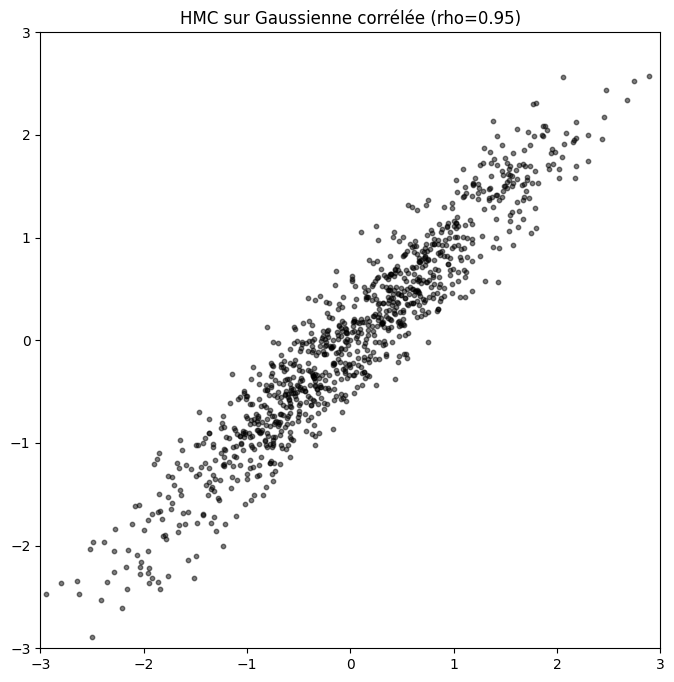

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Définition du problème (Gaussienne corrélée)
cov_matrix = np.array([[1.0, 0.95], [0.95, 1.0]])
inv_cov = np.linalg.inv(cov_matrix)

def potential_energy(q):
    """ U(q) = -log_prob """
    return 0.5 * q.T @ inv_cov @ q

def gradient_potential(q):
    """ dU/dq """
    return inv_cov @ q

def kinetic_energy(p):
    """ K(p) = p^T p / 2 (masse unitaire) """
    return 0.5 * np.sum(p**2)

# 2. Intégrateur Leapfrog (Symplectique)
def leapfrog(q, p, epsilon, L, grad_func):
    """
    Simule la dynamique Hamiltonienne sur L pas de temps discret epsilon.
    q : position (paramètres)
    p : momentum
    """
    q = np.copy(q)
    p = np.copy(p)
    
    # Demi-pas pour le momentum
    p -= epsilon * grad_func(q) / 2
    
    for _ in range(L - 1):
        # Pas complet pour la position
        q += epsilon * p
        # Pas complet pour le momentum
        p -= epsilon * grad_func(q)
    
    # Dernier pas complet pour la position
    q += epsilon * p
    # Dernier demi-pas pour le momentum
    p -= epsilon * grad_func(q) / 2
    
    return q, p

# 3. Algorithme HMC
def hmc_sampler(n_samples, initial_q, epsilon, L):
    samples = [initial_q]
    current_q = initial_q
    
    accepted = 0
    
    for _ in range(n_samples):
        # A. Échantillonnage du momentum (Gibbs step for kinetic energy)
        current_p = np.random.normal(size=current_q.shape)
        
        # B. Intégration Hamiltonienne (Proposal)
        proposed_q, proposed_p = leapfrog(current_q, current_p, epsilon, L, gradient_potential)
        
        # C. Inversion du momentum (pour la réversibilité théorique, 
        # bien que K(p) = K(-p) rende ça invisible en pratique)
        proposed_p = -proposed_p
        
        # D. Metropolis Correction (Energy check)
        # H = U + K. Théoriquement H est conservé, mais l'erreur numérique du Leapfrog nécessite une correction.
        current_H = potential_energy(current_q) + kinetic_energy(current_p)
        proposed_H = potential_energy(proposed_q) + kinetic_energy(proposed_p)
        
        # Ratio d'acceptation : exp(H_start - H_end)
        # Si l'énergie a baissé (ou peu augmenté), on accepte.
        if np.log(np.random.rand()) < current_H - proposed_H:
            current_q = proposed_q
            accepted += 1
            
        samples.append(current_q)
        
    print(f"HMC Acceptance Rate: {accepted/n_samples:.2f}")
    return np.array(samples)

# Exécution
# epsilon : pas de temps (step size)
# L : nombre de pas (path length). L*epsilon = temps d'intégration total
samples = hmc_sampler(n_samples=1000, initial_q=np.array([0., 0.]), epsilon=0.05, L=20)

# Visualisation
plt.figure(figsize=(8, 8))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=10, c='k', label='HMC Samples')
plt.title("HMC sur Gaussienne corrélée (rho=0.95)")
plt.xlim(-3, 3); plt.ylim(-3, 3)
plt.show()